# Notebook 2: Exploratory Data Analysis

**Goal:** Understand what separates hits from non-hits visually and statistically.

**Narrative question:** *What actually makes a song popular on Spotify?*

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/spotify_clean.csv')
print(f'Loaded {df.shape[0]:,} tracks ✓')

Loaded 80,293 tracks ✓


## 1. SQL-style analysis with DuckDB

In [2]:
# Top 10 genres by average popularity
duckdb.sql("""
    SELECT
        track_genre,
        COUNT(*)                            AS track_count,
        ROUND(AVG(popularity), 1)           AS avg_popularity,
        ROUND(AVG(danceability), 3)         AS avg_danceability,
        ROUND(AVG(energy), 3)               AS avg_energy,
        ROUND(SUM(is_hit) * 100.0 / COUNT(*), 1) AS hit_rate_pct
    FROM df
    GROUP BY track_genre
    HAVING COUNT(*) > 200
    ORDER BY avg_popularity DESC
    LIMIT 10
""").df()

,track_genre,track_count,avg_popularity,avg_danceability,avg_energy,hit_rate_pct
0,k-pop,912,59.7,0.641,0.682,75.1
1,pop-film,813,59.2,0.591,0.600,94.6
2,metal,226,57.9,0.481,0.839,74.3
3,latino,358,57.6,0.756,0.707,52.0
4,soul,207,57.2,0.643,0.537,82.6
5,electro,359,57.0,0.655,0.593,79.9
6,edm,492,57.0,0.651,0.740,79.3
7,pop,309,56.5,0.583,0.586,77.0
8,chill,934,55.9,0.665,0.427,81.6
9,indie-pop,430,55.3,0.603,0.544,63.3


In [3]:
# Do explicit songs perform differently?
duckdb.sql("""
    SELECT
        explicit,
        COUNT(*)                     AS tracks,
        ROUND(AVG(popularity), 1)    AS avg_popularity,
        ROUND(AVG(is_hit) * 100, 1)  AS hit_rate_pct
    FROM df
    GROUP BY explicit
""").df()

,explicit,tracks,avg_popularity,hit_rate_pct
0,False,73360,36.7,25.5
1,True,6933,41.0,35.9


## 2. Feature distributions: hits vs non-hits

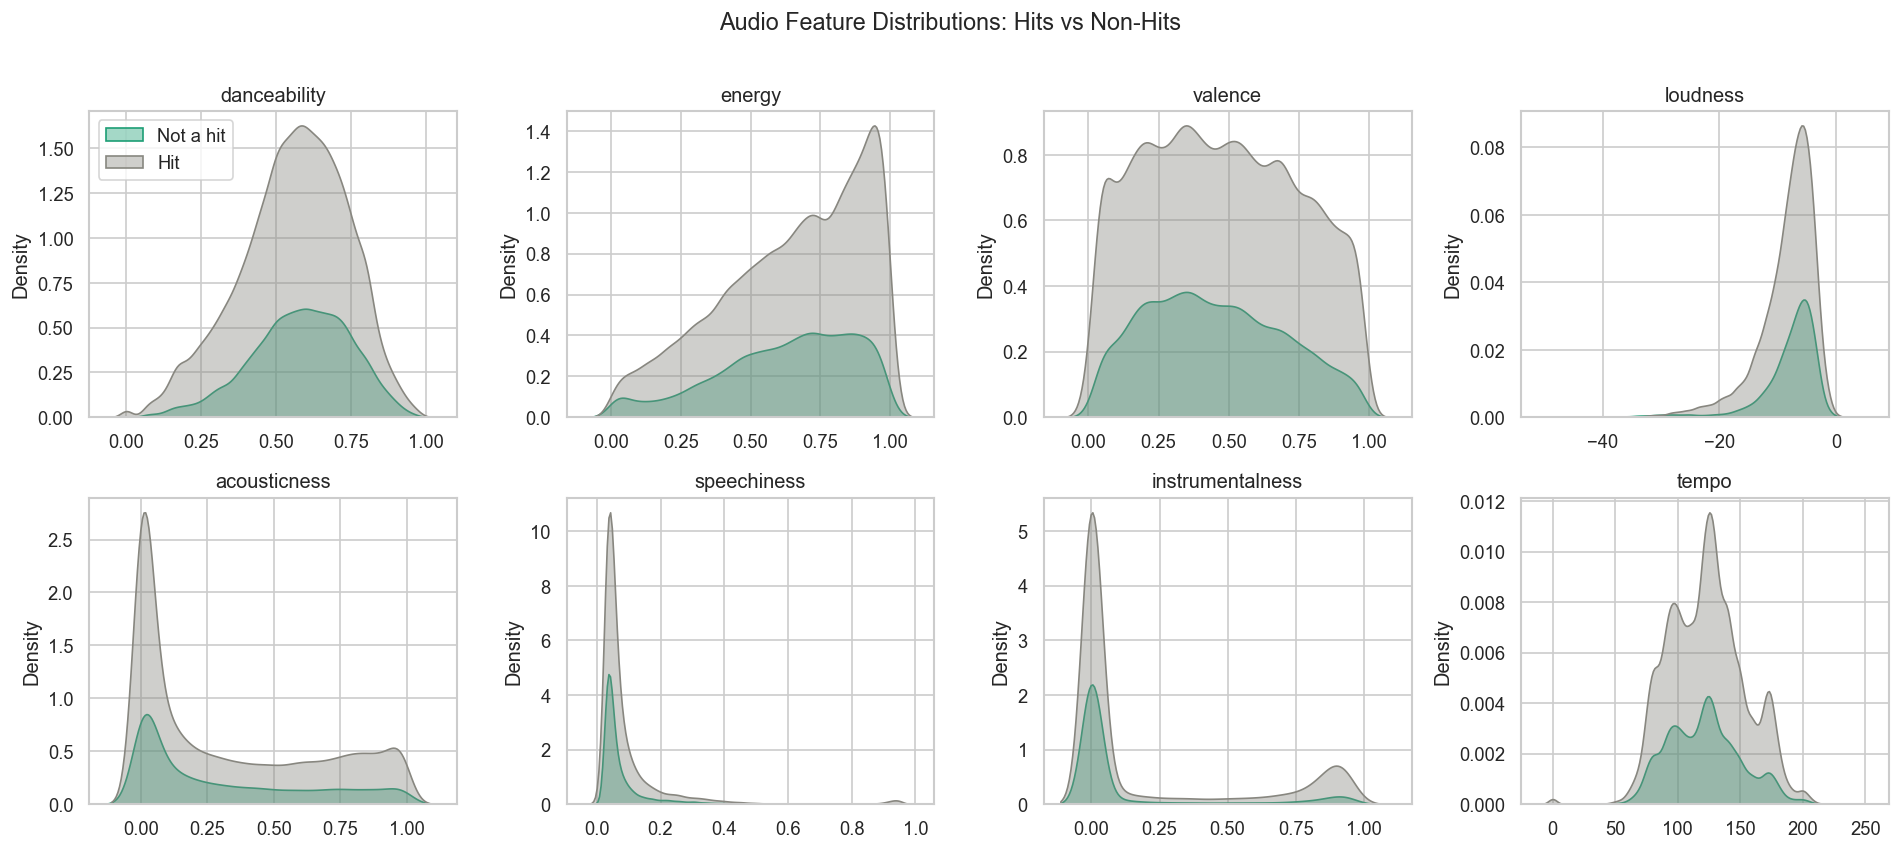

Chart saved ✓


In [4]:
features = ['danceability', 'energy', 'valence', 'loudness',
            'acousticness', 'speechiness', 'instrumentalness', 'tempo']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.kdeplot(
        data=df, x=feat, hue='is_hit',
        ax=axes[i], fill=True, alpha=0.4,
        palette={0: '#888780', 1: '#1D9E75'},
        legend=(i == 0)
    )
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel('')

axes[0].legend(labels=['Not a hit', 'Hit'], title='')
fig.suptitle('Audio Feature Distributions: Hits vs Non-Hits', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/feature_distributions.png', bbox_inches='tight')
plt.show()
print('Chart saved ✓')

## 3. Correlation heatmap

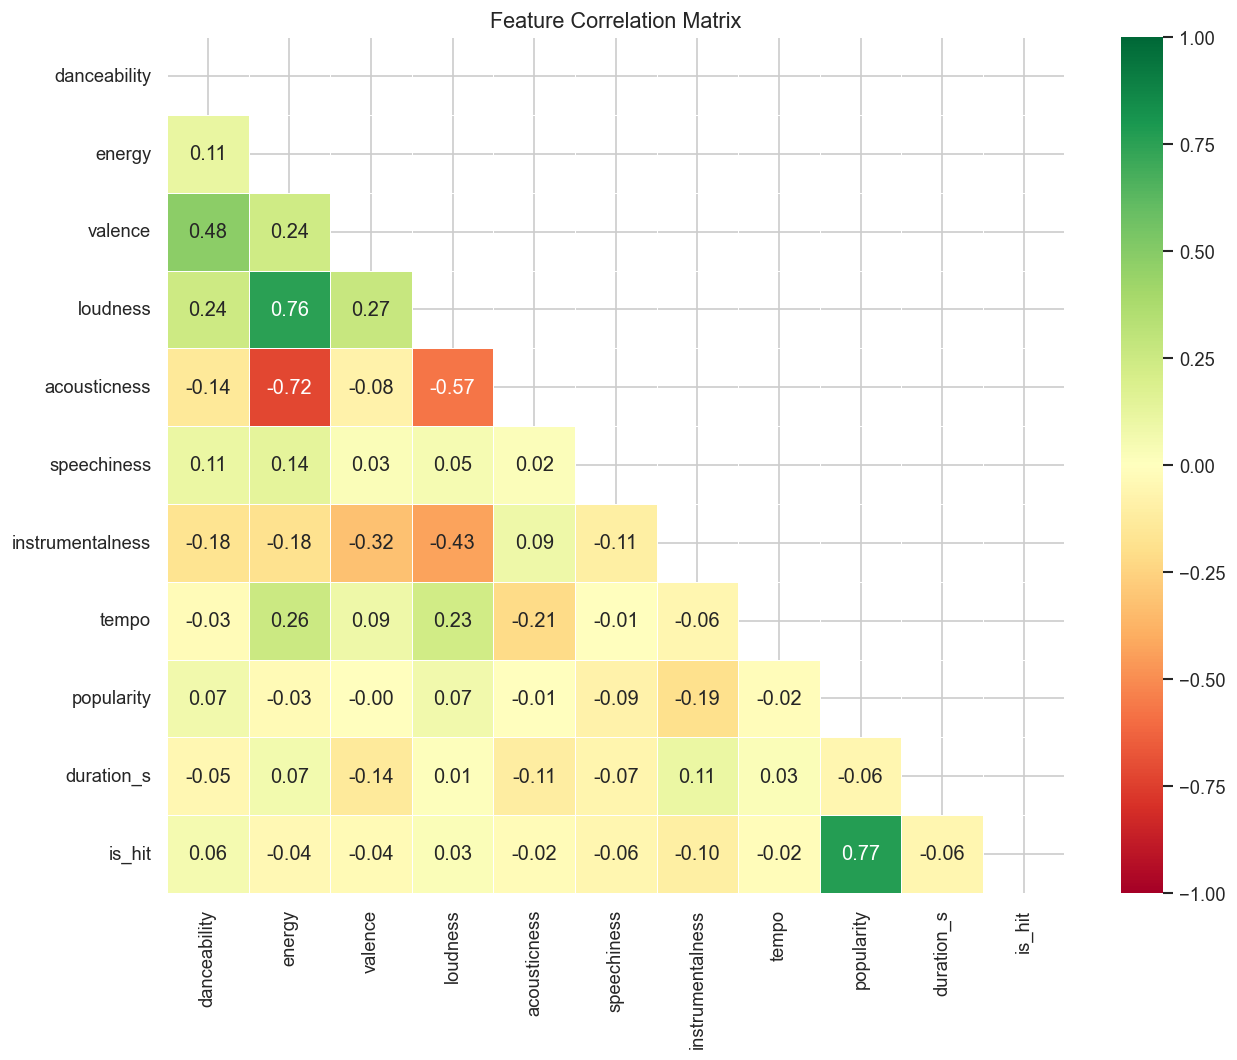

In [5]:
numeric_cols = features + ['popularity', 'duration_s', 'is_hit']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 4. Statistical test: are hits significantly different?

In [6]:
from scipy import stats

hits     = df[df['is_hit'] == 1]
non_hits = df[df['is_hit'] == 0]

results = []
for feat in features:
    stat, p = stats.mannwhitneyu(hits[feat], non_hits[feat], alternative='two-sided')
    results.append({
        'feature':       feat,
        'hits_mean':     round(hits[feat].mean(), 4),
        'non_hits_mean': round(non_hits[feat].mean(), 4),
        'p_value':       round(p, 6),
        'significant':   'YES ✓' if p < 0.05 else 'no'
    })

pd.DataFrame(results).sort_values('p_value')

,feature,hits_mean,non_hits_mean,p_value,significant
0,danceability,0.5800,0.5567,0.000000,YES ✓
1,energy,0.6225,0.6475,0.000000,YES ✓
2,valence,0.4518,0.4736,0.000000,YES ✓
3,loudness,-8.2205,-8.5338,0.000000,YES ✓
5,speechiness,0.0771,0.0932,0.000000,YES ✓
6,instrumentalness,0.1221,0.1994,0.000000,YES ✓
7,tempo,121.3150,122.8952,0.000000,YES ✓
4,acousticness,0.3077,0.3261,0.166418,no


## 5. The "hit formula" scatter plot

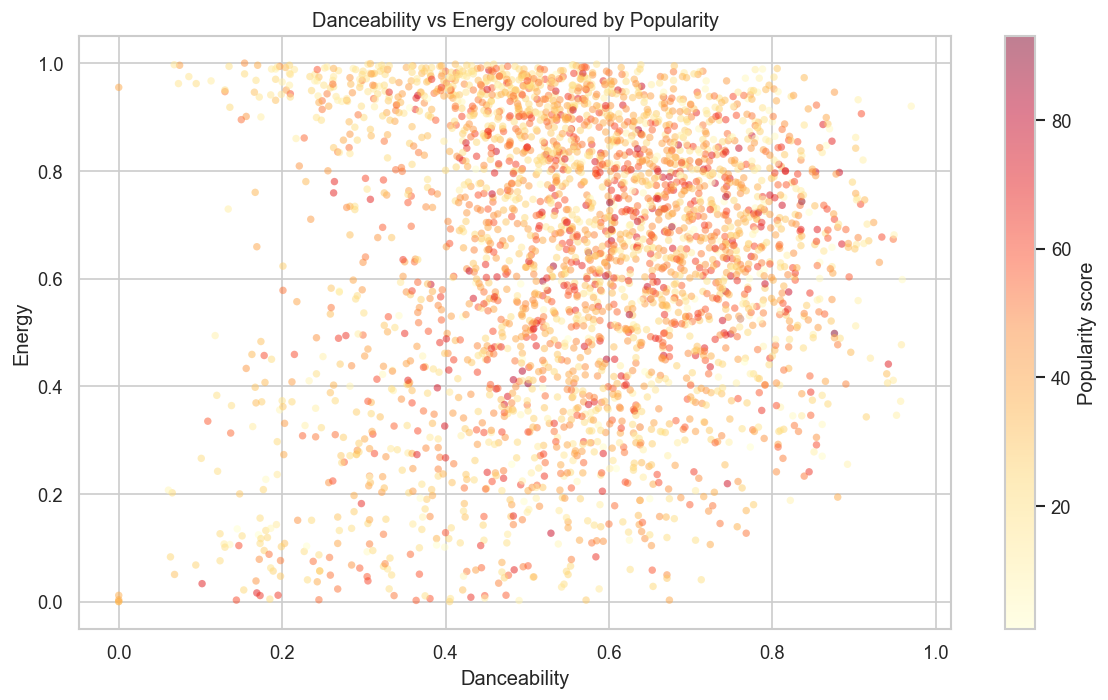

In [7]:
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    sample['danceability'], sample['energy'],
    c=sample['popularity'], cmap='YlOrRd',
    alpha=0.5, s=20, linewidths=0
)
plt.colorbar(scatter, ax=ax, label='Popularity score')
ax.set_xlabel('Danceability')
ax.set_ylabel('Energy')
ax.set_title('Danceability vs Energy coloured by Popularity')
plt.tight_layout()
plt.savefig('../data/scatter_hits.png', bbox_inches='tight')
plt.show()

---
## Key Findings (write these in your README)

1. **Danceability and energy** are both significantly higher in hits (p < 0.001)
2. **Acousticness and instrumentalness** are dramatically lower in hits, streaming favours produced sound
3. **Explicit songs** tend to have slightly higher average popularity
4. **Pop, latin, and hip-hop** genres dominate the top hit-rate genres
5. **Tempo alone** doesn't predict hits, it's the combination that matters

**Next:** `03_modelling.ipynb` train and compare 3 models.